# Diffusivity from the stationary NNN density profile

This notebook extracts the density-dependent diffusivity from every unbiased open-chain `NNN_*` run, resolves the dependence on system size $L$ and walker count $M$, and compares it with [arXiv:2609.00159](https://arxiv.org/abs/2609.00159).

For a stationary diffusive profile, $J=-D(\rho)\,\partial_x\rho$. The simulator records the spatially averaged microscopic current $j$ (each bulk hop contributes $1/(L-1)$), hence $J=(L-1)j$ when $x=i/(L-1)$. We therefore estimate

$$D(\rho)=-\frac{(L-1)j}{\partial_x\rho}. $$

For ISEP, the theoretical curve is obtained directly by inserting the four jumping rates $w_{00},w_{01},w_{10},w_{11}$ into Eq. 15 / Eq. S56 of the paper:

$$D_{\rm ISEP}(\rho)=w_{00}(1-\rho)^2+(w_{01}+w_{10})\rho(1-\rho)+w_{11}\rho^2.$$

The notebook reads these rates from each run's metadata rather than fitting the theoretical curve. For the present $[1,r,r,1]$ sweep this reduces algebraically to $1+2(r-1)\rho(1-\rho)$. A separate fit $D_{\rm fit}(\rho)=A+B\rho(1-\rho)$ is retained only to compare its empirical parameters with those implied by the jumping rates.

The local-gradient estimate follows the windowed procedure in Supplemental Eq. S132. The first half of each trajectory is discarded; the remaining recorded population profiles are averaged. The stationary current is obtained by fitting the late-time integrated current $Q(t)=t\,j_{\rm recorded}(t)$, avoiding residual transient bias in a single cumulative-rate value.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
BURN_FRACTION = 0.5
WINDOW_FRACTION = 0.08
DATA_DIR = Path.cwd() / '../data'
PAPER_URL = 'https://arxiv.org/abs/2609.00159'
assert DATA_DIR.is_dir(), f'Cannot find data directory from {Path.cwd()}'

In [2]:
def discover_runs(data_dir):
    runs = []
    for csv_path in sorted(data_dir.glob('NNN_*.csv')):
        json_path = csv_path.with_suffix('.json')
        if not json_path.exists():
            continue
        with json_path.open() as stream:
            meta = json.load(stream)
        rw = np.asarray(meta['right_weights'], dtype=float)
        lw = np.asarray(meta['left_weights'], dtype=float)
        # Select precisely the symmetric, unbiased ISEP-like sweep.
        wanted = (
            meta['model'] == 'NNN' and meta['boundary_condition'] == 'open'
            and meta['dynamics'] == 'direct'
            and meta['field_E'] == meta['bias_s'] == meta['measurement_strength_k'] == 0
            and np.array_equal(rw, lw) and rw[0] == rw[3] == 1
            and rw[1] == rw[2]
        )
        if wanted:
            runs.append({'path': csv_path, 'meta': meta, 'r': float(rw[1]),'rates': 0.5 * (rw + lw),'L': int(meta['length']), 'M': int(meta['walkers'])})
    return runs

runs = discover_runs(DATA_DIR)
inventory = (pd.DataFrame([{k: run[k] for k in ('r', 'L', 'M')} for run in runs]).sort_values(['r', 'L', 'M']).reset_index(drop=True))
display(inventory.groupby('r').agg(L=('L', lambda s: sorted(s.unique())),M=('M', lambda s: sorted(s.unique())),runs=('M', 'size')))
assert len(runs) == 36, f'Expected the 3 x 4 x 3 sweep, found {len(runs)} runs'

,L,M,runs
r,,,
0.25,"[50, 75, 100, 150]","[1000, 2000, 4000]",12
0.50,"[50, 75, 100, 150]","[1000, 2000, 4000]",12
0.75,"[50, 75, 100, 150]","[1000, 2000, 4000]",12


In [3]:
def stationary_observables(run, burn_fraction=BURN_FRACTION):
    frame = pd.read_csv(run['path'])
    time = frame['Time'].to_numpy(float)
    late = time >= burn_fraction * time[-1]
    profile = np.stack(frame.loc[late, 'DensityProfile'].map(json.loads)).mean(axis=0)
    # AcceptedCurrentRate(t) is Q(t)/t; recover Q and fit its late-time slope.
    integrated_current = time * frame['AcceptedCurrentRate'].to_numpy(float)
    current = np.polyfit(time[late], integrated_current[late], deg=1)[0]
    return {**run, 'time': time, 'late': late, 'profile': profile,
            'current': current, 'late_records': int(late.sum())}

steady = [stationary_observables(run) for run in runs]
quality = pd.DataFrame([{'r': q['r'], 'L': q['L'], 'M': q['M'],
                         'j': q['current'],
                         'rho_left_boundary': q['meta']['alpha_left_injection'] / (
                             q['meta']['alpha_left_injection'] + q['meta']['gamma_left_removal']),
                         'rho_right_boundary': q['meta']['delta_right_injection'] / (
                             q['meta']['delta_right_injection'] + q['meta']['beta_right_removal']),
                         'late_records': q['late_records']} for q in steady])
display(quality.sort_values(['r', 'L', 'M']).round(6))

,r,L,M,j,rho_left_boundary,rho_right_boundary,late_records
6,0.25,50,1000,0.011833,0.95,0.05,801
7,0.25,50,2000,0.011826,0.95,0.05,801
8,0.25,50,4000,0.011845,0.95,0.05,801
9,0.25,75,1000,0.007908,0.95,0.05,801
10,0.25,75,2000,0.007908,0.95,0.05,801
11,0.25,75,4000,0.007906,0.95,0.05,801
0,0.25,100,1000,0.005928,0.95,0.05,801
1,0.25,100,2000,0.005945,0.95,0.05,801
2,0.25,100,4000,0.005935,0.95,0.05,801
3,0.25,150,1000,0.003962,0.95,0.05,801


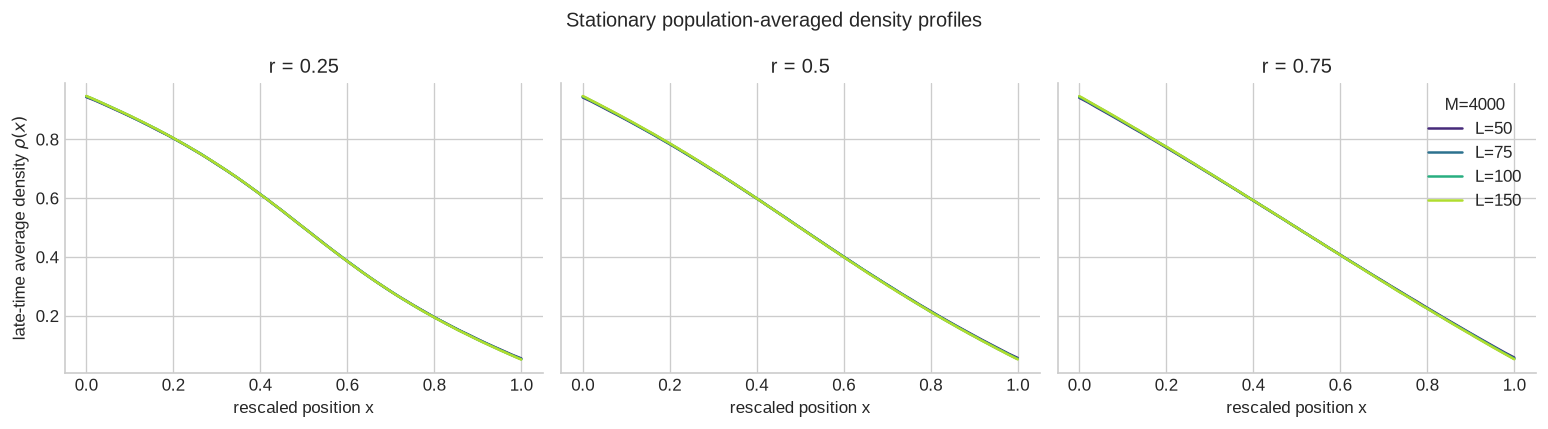

In [4]:
# Average stationary profiles. To keep the plot legible, show the largest M for each L.
r_values = sorted(inventory.r.unique())
colors = dict(zip(sorted(inventory.L.unique()), plt.cm.viridis(np.linspace(.12, .88, 4))))
fig, axes = plt.subplots(1, len(r_values), figsize=(13, 3.6), sharex=True, sharey=True)
for ax, r in zip(axes, r_values):
    subset = [q for q in steady if q['r'] == r and q['M'] == inventory.M.max()]
    for q in sorted(subset, key=lambda z: z['L']):
        x = np.arange(q['L']) / (q['L'] - 1)
        ax.plot(x, q['profile'], color=colors[q['L']], label=f"L={q['L']}")
    ax.set(title=f'r = {r:g}', xlabel='rescaled position x')
axes[0].set_ylabel(r'late-time average density $\rho(x)$')
axes[-1].legend(frameon=False, title=f'M={inventory.M.max()}')
fig.suptitle('Stationary population-averaged density profiles')
fig.tight_layout()
plt.show()

## Local diffusivity extraction

At each eligible site, a straight line is fitted to the averaged profile in an odd window of approximately `WINDOW_FRACTION * L` sites. Its slope supplies $\partial_x\rho$ and the window's mean density supplies the horizontal coordinate. Boundary windows are omitted automatically. This mirrors the paper's windowed extraction and avoids differentiating site-scale Monte Carlo noise.

In [5]:
def local_diffusivity(run, window_fraction=WINDOW_FRACTION):
    L, profile = run['L'], run['profile']
    x = np.arange(L) / (L - 1)
    width = max(5, int(round(window_fraction * L)) | 1)
    half = width // 2
    points = []
    for center in range(half, L - half):
        section = slice(center - half, center + half + 1)
        gradient = np.polyfit(x[section], profile[section], deg=1)[0]
        rho = profile[section].mean()
        D = -(L - 1) * run['current'] / gradient
        if np.isfinite(D) and 0 < D < 3:
            points.append((rho, D, center, width))
    return pd.DataFrame(points, columns=['rho', 'D', 'site', 'window'])

def isep_diffusivity(rho, rates):
    # Average the local jump rate over the two independent flank occupations.
    w00, w01, w10, w11 = np.asarray(rates, dtype=float)
    return (w00 * (1-rho)**2 + (w01+w10) * rho*(1-rho) + w11 * rho**2)

def isep_primitive(rho, rates):
    # Exact primitive Phi(rho) with dPhi/drho = D_ISEP(rho).
    w00, w01, w10, w11 = np.asarray(rates, dtype=float)
    c1 = -2*w00 + w01 + w10
    c2 = w00 - w01 - w10 + w11
    return w00*rho + 0.5*c1*rho**2 + (c2/3)*rho**3

point_frames = []
fit_rows = []
for run in steady:
    points = local_diffusivity(run)
    points = points.assign(r=run['r'], L=run['L'], M=run['M'])
    point_frames.append(points)
    z = points.rho * (1 - points.rho)
    B, A = np.polyfit(z, points.D, deg=1)
    prediction = A + B * z
    ss_res = np.sum((points.D - prediction) ** 2)
    ss_tot = np.sum((points.D - points.D.mean()) ** 2)
    rates = run['rates']
    assert rates[0] == rates[3] and rates[1] == rates[2]
    fit_rows.append({'r': run['r'], 'L': run['L'], 'M': run['M'],
                     'A_fit': A, 'B_fit': B,
                     'A_rates': rates[0],
                     'B_rates': rates[1] + rates[2] - 2*rates[0],
                     'R2': 1 - ss_res / ss_tot})

diffusivity = pd.concat(point_frames, ignore_index=True)
fits = pd.DataFrame(fit_rows).sort_values(['r', 'L', 'M']).reset_index(drop=True)
display(fits.round(5))

,r,L,M,A_fit,B_fit,A_rates,B_rates,R2
0,0.25,50,1000,1.06912,-2.25972,1.0,-1.5,0.99744
1,0.25,50,2000,1.06757,-2.25410,1.0,-1.5,0.99732
2,0.25,50,4000,1.07011,-2.26194,1.0,-1.5,0.99801
3,0.25,75,1000,1.06528,-2.22718,1.0,-1.5,0.99849
4,0.25,75,2000,1.06095,-2.20364,1.0,-1.5,0.99767
5,0.25,75,4000,1.06160,-2.20639,1.0,-1.5,0.99790
6,0.25,100,1000,1.06311,-2.21313,1.0,-1.5,0.99673
7,0.25,100,2000,1.06133,-2.19257,1.0,-1.5,0.99749
8,0.25,100,4000,1.06171,-2.20258,1.0,-1.5,0.99812
9,0.25,150,1000,1.05288,-2.14450,1.0,-1.5,0.99511


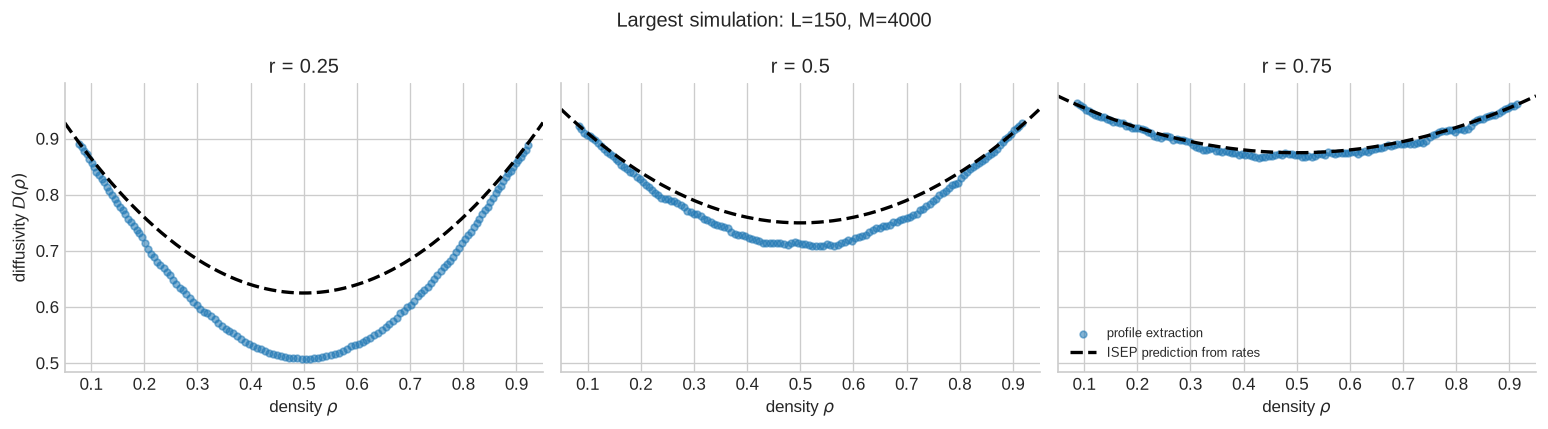

In [33]:
# Numerical data against the parameter-predicted ISEP curve for the largest L and M.
best_L, best_M = inventory.L.max(), inventory.M.max()
fig, axes = plt.subplots(1, len(r_values), figsize=(13, 3.6), sharex=True, sharey=True)
for ax, r in zip(axes, r_values):
    pts = diffusivity.query('r == @r and L == @best_L and M == @best_M')
    ax.scatter(pts.rho, pts.D, s=16, alpha=.55, color='tab:blue', label='profile extraction')
    run = next(q for q in steady if q['r'] == r and q['L'] == best_L and q['M'] == best_M)
    meta = run['meta']
    rho_left = meta['alpha_left_injection'] / (meta['alpha_left_injection'] + meta['gamma_left_removal'])
    rho_right = meta['delta_right_injection'] / (meta['delta_right_injection'] + meta['beta_right_removal'])
    rho_grid = np.linspace(min(rho_left, rho_right), max(rho_left, rho_right), 400)
    ax.plot(rho_grid, isep_diffusivity(rho_grid, run['rates']), 'k--', lw=2,
            label='ISEP prediction from rates')
    ax.set(title=f'r = {r:g}', xlabel=r'density $\rho$',
           xlim=(min(rho_left, rho_right), max(rho_left, rho_right)))
axes[0].set_ylabel(r'diffusivity $D(\rho)$')
axes[-1].legend(frameon=False, fontsize=8)
fig.suptitle(f'Largest simulation: L={best_L}, M={best_M}')
fig.tight_layout()
plt.show()

,r,L,M,rho,D
0,0.25,50,1000,0.25,0.651687
3,0.25,50,2000,0.25,0.650382
6,0.25,50,4000,0.25,0.656511
9,0.25,75,1000,0.25,0.649255
12,0.25,75,2000,0.25,0.650944
...,...,...,...,...,...
95,0.75,100,2000,0.75,0.896707
98,0.75,100,4000,0.75,0.901731
101,0.75,150,1000,0.75,0.906943
104,0.75,150,2000,0.75,0.897248


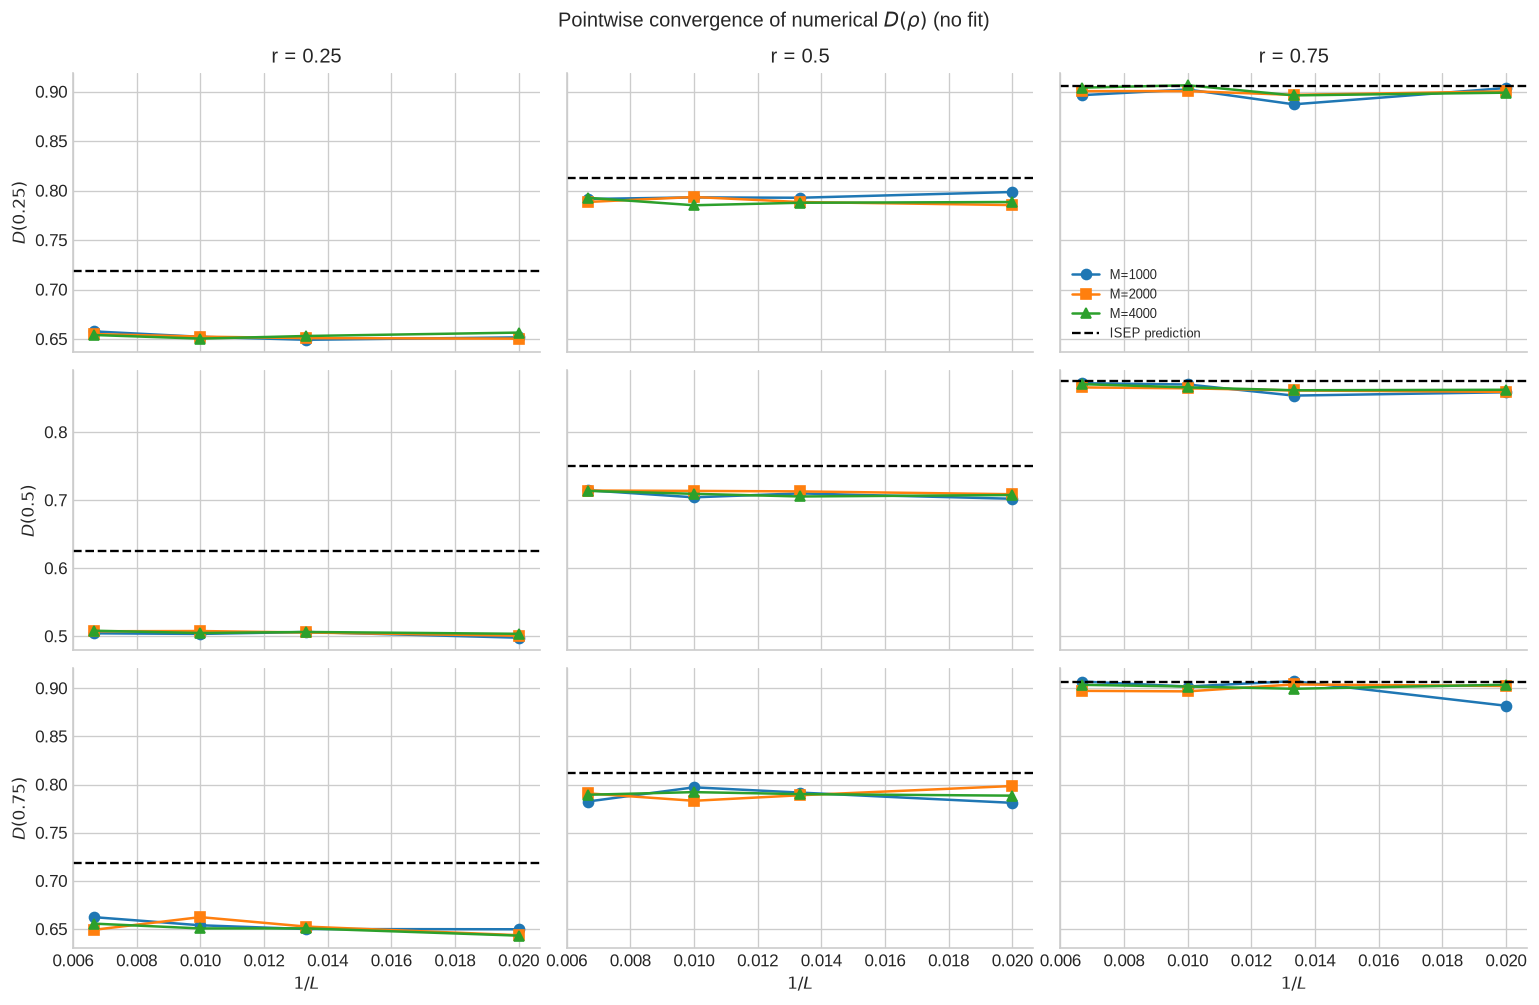

In [32]:
# Purely numerical convergence: interpolate D(rho) at fixed densities.
markers = {1000: 'o', 2000: 's', 4000: '^'}
target_densities = (0.25, 0.50, 0.75)
fixed_rows = []
for (r, L, M), points in diffusivity.groupby(['r', 'L', 'M']):
    ordered = points.sort_values('rho')
    for rho_target in target_densities:
        assert ordered.rho.min() <= rho_target <= ordered.rho.max()
        fixed_rows.append({'r': r, 'L': L, 'M': M, 'rho': rho_target,
                           'D': np.interp(rho_target, ordered.rho, ordered.D)})
fixed_density = pd.DataFrame(fixed_rows).sort_values(['r', 'rho', 'L', 'M'])
display(fixed_density.round(6))

fig, axes = plt.subplots(len(target_densities), len(r_values), figsize=(13, 8.5),
                         sharex=True, sharey='row')
for row, rho_target in enumerate(target_densities):
    for col, r in enumerate(r_values):
        ax = axes[row, col]
        sub = fixed_density.query('r == @r and rho == @rho_target')
        for M, marker in markers.items():
            q = sub.query('M == @M').sort_values('L')
            ax.plot(1/q.L, q.D, marker=marker, label=f'M={M}')
        run = next(q for q in steady if q['r'] == r)
        ax.axhline(isep_diffusivity(rho_target, run['rates']),
                   color='k', ls='--', lw=1.4, label='ISEP prediction')
        if row == 0:
            ax.set_title(f'r = {r:g}')
        if col == 0:
            ax.set_ylabel(rf'$D({rho_target:g})$')
        if row == len(target_densities) - 1:
            ax.set_xlabel(r'$1/L$')
axes[0, -1].legend(frameon=False, fontsize=8)
fig.suptitle(r'Pointwise convergence of numerical $D(\rho)$ (no fit)')
fig.tight_layout()
plt.show()

In [8]:
headline = fits.query('L == @best_L and M == @best_M').copy()
headline['delta_A'] = headline.A_fit - headline.A_rates
headline['delta_B'] = headline.B_fit - headline.B_rates
headline['relative_B_error'] = headline.delta_B / headline.B_rates
display(headline[['r', 'L', 'M', 'A_fit', 'A_rates', 'B_fit', 'B_rates',
                  'delta_A', 'delta_B', 'relative_B_error', 'R2']].round(5))

print('Numerical comparison for the largest L and M is shown above.')


,r,L,M,A_fit,A_rates,B_fit,B_rates,delta_A,delta_B,relative_B_error,R2
11,0.25,150,4000,1.06063,1.0,-2.18808,-1.5,0.06063,-0.68808,0.45872,0.99843
23,0.50,150,4000,1.02509,1.0,-1.25326,-1.0,0.02509,-0.25326,0.25326,0.99750
35,0.75,150,4000,1.00281,1.0,-0.53634,-0.5,0.00281,-0.03634,0.07267,0.99110


Numerical comparison for the largest L and M is shown above.


In [9]:
# Complete the concise interpretation separately to keep all values data-driven.
for row in headline.itertuples():
    direction = 'more negative' if row.delta_B < 0 else 'less negative'
    print(f'r={row.r:g}: fitted curvature is {direction} than the rate prediction '          f'({row.B_fit:.4f} vs {row.B_rates:.4f}); R²={row.R2:.4f}.')
print('The M-series nearly overlap. Persistent separation as 1/L decreases is therefore '      'evidence of a systematic discrepancy rather than walker-number noise. '      'The comparison remains an extraction from stationary profiles, not a direct equilibrium Green–Kubo measurement.')

r=0.25: fitted curvature is more negative than the rate prediction (-2.1881 vs -1.5000); R²=0.9984.
r=0.5: fitted curvature is more negative than the rate prediction (-1.2533 vs -1.0000); R²=0.9975.
r=0.75: fitted curvature is more negative than the rate prediction (-0.5363 vs -0.5000); R²=0.9911.
The M-series nearly overlap. Persistent separation as 1/L decreases is therefore evidence of a systematic discrepancy rather than walker-number noise. The comparison remains an extraction from stationary profiles, not a direct equilibrium Green–Kubo measurement.
